# Week 3 — Chooser Option (Paper Params) Reproduction



目标：用论文给定参数，复现 **chooser option** 在 **BSM** 下的 Monte Carlo 定价“数值行为”（数量级、单调性、敏感性方向），并做基本逻辑验证。



论文参数（你提供）：

- `K = 150`

- `T1 = 0.5`

- `T2 = 1.0`

- `S0 = 156.7`

- `sigma = 0.282`

- `r = 0.0015`（0.15%）

- `q = 0.0233`（dividend yield 2.33%）



说明：此处用连续复利 `r, q`，贴现因子 `exp(-rT)`。

In [78]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass
from typing import Any


# Best-effort: use numpy if available for speed
try:
    import numpy as np  # type: ignore
    HAS_NUMPY = True
except Exception:
    np = None
    HAS_NUMPY = False

HAS_NUMPY

True

## 1) Model definition



Chooser option（常见定义）：在 `T1` 时刻，你可以选择持有一份 European **call** 或 **put**（同一 `K`、同一到期 `T2`）。因此到 `T2` 的 payoff 为：



- 若在 `T1` 选择 call：`max(S(T2)-K, 0)`

- 若在 `T1` 选择 put：`max(K-S(T2), 0)`



关键是 `T1` 的决策规则。

在 BSM 下（同 `K, T2`），决策边界可以写成对 `S(T1)` 的阈值：



$$S^* = K \cdot \exp\left(-(r-q)(T2-T1)\right)$$



- 若 `S(T1) >= S*`，选择 call

- 否则选择 put



（当 `r≈q≈0` 时，`S*≈K`，所以很多人会简写成“`S(T1) > K` 选 call”。）

In [79]:
@dataclass(frozen=True)
class Params:
    S0: float
    K: float
    T1: float
    T2: float
    sigma: float
    r: float
    q: float


P = Params(
    S0=156.7,
    K=150.0,
    T1=0.5,
    T2=1.0,
    sigma=0.282,
    r=0.0015,
    q=0.0233,
)

assert 0.0 < P.T1 < P.T2
assert P.S0 > 0 and P.K > 0 and P.sigma > 0

S_star = P.K * math.exp(-(P.r - P.q) * (P.T2 - P.T1))
S_star

151.64394321414153

## 2) Two-stage BSM simulation



在风险中性测度下：



$$S(t+\Delta t) = S(t)\,\exp\left((r-q-\tfrac12\sigma^2)\Delta t + \sigma\sqrt{\Delta t}\,Z\right)$$



我们分两段模拟：`0→T1`，再从 `T1→T2`。

In [80]:
def chooser_decision(S_t1: float, *, K: float, T1: float, T2: float, r: float, q: float) -> str:
    S_star = K * math.exp(-(r - q) * (T2 - T1))
    return 'CALL' if S_t1 >= S_star else 'PUT'


def payoff_at_T2(S_t2: float, *, K: float, choice: str) -> float:
    if str(choice).upper() == 'CALL':
        return max(S_t2 - K, 0.0)
    return max(K - S_t2, 0.0)


def _box_muller() -> float:
    # Standard normal using Box-Muller
    u1 = max(1e-12, random.random())
    u2 = random.random()
    return math.sqrt(-2.0 * math.log(u1)) * math.cos(2.0 * math.pi * u2)


def simulate_one_path(P: Params) -> dict[str, Any]:
    dt1 = P.T1
    dt2 = P.T2 - P.T1
    drift1 = (P.r - P.q - 0.5 * P.sigma**2) * dt1
    drift2 = (P.r - P.q - 0.5 * P.sigma**2) * dt2
    vol1 = P.sigma * math.sqrt(dt1)
    vol2 = P.sigma * math.sqrt(dt2)

    z1 = _box_muller()
    z2 = _box_muller()
    S_t1 = P.S0 * math.exp(drift1 + vol1 * z1)
    choice = chooser_decision(S_t1, K=P.K, T1=P.T1, T2=P.T2, r=P.r, q=P.q)
    S_t2 = S_t1 * math.exp(drift2 + vol2 * z2)
    payoff = payoff_at_T2(S_t2, K=P.K, choice=choice)
    return {
        'S_T1': S_t1,
        'choice': choice,
        'S_T2': S_t2,
        'payoff': payoff,
    }


# Show a few sample paths for logic validation
random.seed(1)
paths = [simulate_one_path(P) for _ in range(10)]
paths[:3]

[{'S_T1': 191.16660300558289,
  'choice': 'CALL',
  'S_T2': 184.50980464260178,
  'payoff': 34.50980464260178},
 {'S_T1': 121.39199822356504,
  'choice': 'PUT',
  'S_T2': 123.06431854639139,
  'payoff': 26.93568145360861},
 {'S_T1': 232.86359242249958,
  'choice': 'CALL',
  'S_T2': 202.49729646257214,
  'payoff': 52.49729646257214}]

把上面 `paths` 展成表格（如果没有 pandas，也可以直接看 list）。

In [81]:
try:
    import pandas as pd  # type: ignore
    df_paths = pd.DataFrame(paths)
    df_paths
except Exception:
    paths

## 3) Monte Carlo pricing



价格：

$$Price = e^{-rT2}\,\mathbb{E}[payoff]$$



同时给出标准误差和 95% 置信区间（便于和论文数量级/方向做对比）。

In [82]:
@dataclass(frozen=True)
class MCResult:
    price: float
    stderr: float
    ci95_low: float
    ci95_high: float
    p_choose_call: float


def mc_price(P: Params, *, n_paths: int = 200_000, seed: int = 7) -> MCResult:
    if not (0.0 < P.T1 < P.T2):
        raise ValueError('Require 0 < T1 < T2')
    if P.sigma <= 0:
        raise ValueError('sigma must be > 0')

    dt1 = float(P.T1)
    dt2 = float(P.T2 - P.T1)
    drift1 = (P.r - P.q - 0.5 * P.sigma * P.sigma) * dt1
    drift2 = (P.r - P.q - 0.5 * P.sigma * P.sigma) * dt2
    vol1 = P.sigma * math.sqrt(dt1)
    vol2 = P.sigma * math.sqrt(dt2)
    disc = math.exp(-P.r * P.T2)
    S_star = P.K * math.exp(-(P.r - P.q) * (P.T2 - P.T1))

    if HAS_NUMPY:
        rng = np.random.default_rng(int(seed))
        z1 = rng.standard_normal(int(n_paths))
        z2 = rng.standard_normal(int(n_paths))
        S_t1 = P.S0 * np.exp(drift1 + vol1 * z1)
        S_t2 = S_t1 * np.exp(drift2 + vol2 * z2)
        choose_call = S_t1 >= S_star
        payoff = np.where(choose_call, np.maximum(S_t2 - P.K, 0.0), np.maximum(P.K - S_t2, 0.0))
        pv = disc * payoff
        price = float(pv.mean())
        stderr = float(pv.std(ddof=1) / math.sqrt(float(n_paths)))
        ci95 = 1.96 * stderr
        return MCResult(price=price, stderr=stderr, ci95_low=price - ci95, ci95_high=price + ci95, p_choose_call=float(choose_call.mean()))

    # Pure-python fallback
    random.seed(int(seed))
    pv_list = []
    choose_call_count = 0
    for _ in range(int(n_paths)):
        z1 = _box_muller()
        z2 = _box_muller()
        S_t1 = P.S0 * math.exp(drift1 + vol1 * z1)
        S_t2 = S_t1 * math.exp(drift2 + vol2 * z2)
        is_call = S_t1 >= S_star
        choose_call_count += 1 if is_call else 0
        payoff = max(S_t2 - P.K, 0.0) if is_call else max(P.K - S_t2, 0.0)
        pv_list.append(disc * payoff)
    n = float(n_paths)
    mean = sum(pv_list) / n
    var = sum((x - mean) ** 2 for x in pv_list) / (n - 1.0) if n_paths > 1 else 0.0
    stderr = math.sqrt(var) / math.sqrt(n)
    ci95 = 1.96 * stderr
    return MCResult(price=float(mean), stderr=float(stderr), ci95_low=float(mean - ci95), ci95_high=float(mean + ci95), p_choose_call=float(choose_call_count / n))


res = mc_price(P, n_paths=200_000, seed=7)
res

MCResult(price=29.106050979013137, stderr=0.06858185793945526, ci95_low=28.971630537451805, ci95_high=29.24047142057447, p_choose_call=0.50414)

## 4) 数值行为验证（方向/敏感性）

按论文常见展示方式：在同一张图里用 **两条线** 同时画出 **vanilla call** 与 **vanilla put** 的价格随参数变化的关系。

验证方向（BSM 常识）：
- `sigma ↑ → call ↑, put ↑`
- `K ↑ → call ↓, put ↑`
- `r ↑ → call ↑, put ↓`
- `q ↑ → call ↓, put ↑`

说明：这里用 BSM 解析定价（无 Monte Carlo 噪声），到期统一取 `T = T2`。


In [83]:
def _norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def bs_vanilla_price(*, is_call: bool, S0: float, K: float, T: float, r: float, q: float, sigma: float) -> float:
    if T <= 0:
        return max(0.0, (S0 - K) if is_call else (K - S0))
    if sigma <= 0:
        fwd = S0 * math.exp((r - q) * T)
        disc = math.exp(-r * T)
        intrinsic = max(0.0, (fwd - K) if is_call else (K - fwd))
        return disc * intrinsic
    sqrtT = math.sqrt(T)
    d1 = (math.log(S0 / K) + (r - q + 0.5 * sigma * sigma) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    df_r = math.exp(-r * T)
    df_q = math.exp(-q * T)
    if is_call:
        return S0 * df_q * _norm_cdf(d1) - K * df_r * _norm_cdf(d2)
    return K * df_r * _norm_cdf(-d2) - S0 * df_q * _norm_cdf(-d1)


def vanilla_table(param: str, values: list[float], *, base: Params):
    rows = []
    for v in values:
        d = base.__dict__.copy()
        d[param] = float(v)
        p2 = Params(**d)
        T = float(p2.T2)
        call = bs_vanilla_price(is_call=True, S0=p2.S0, K=p2.K, T=T, r=p2.r, q=p2.q, sigma=p2.sigma)
        put = bs_vanilla_price(is_call=False, S0=p2.S0, K=p2.K, T=T, r=p2.r, q=p2.q, sigma=p2.sigma)
        rows.append({param: float(v), 'call_price': float(call), 'put_price': float(put)})
    try:
        import pandas as pd  # type: ignore
        return pd.DataFrame(rows)
    except Exception:
        return rows


sigma_grid = [0.15, 0.20, 0.282, 0.35, 0.45]
K_grid = [130, 140, 150, 160, 170]
r_grid = [0.0, 0.0015, 0.01, 0.03]
q_grid = [0.0, 0.0233, 0.05]

df_sigma = vanilla_table('sigma', sigma_grid, base=P)
df_K = vanilla_table('K', K_grid, base=P)
df_r = vanilla_table('r', r_grid, base=P)
df_q = vanilla_table('q', q_grid, base=P)

df_sigma


,sigma,call_price,put_price
0,0.150,10.807554,7.491626
1,0.200,13.792458,10.476530
2,0.282,18.688997,15.373069
3,0.350,22.735851,19.419922
4,0.450,28.647576,25.331648


In [84]:
df_K

,K,call_price,put_price
0,130.0,30.118730,6.832779
1,140.0,23.910141,10.609202
2,150.0,18.688997,15.373069
3,160.0,14.404249,21.073332
4,170.0,10.963686,27.617781


In [85]:
df_r

,r,call_price,put_price
0,0.0000,18.582498,15.491401
1,0.0015,18.688997,15.373069
2,0.0100,19.298428,14.714806
3,0.0300,20.771257,13.246990


In [86]:
df_q

,q,call_price,put_price
0,0.0000,20.863678,13.938846
1,0.0233,18.688997,15.373069
2,0.0500,16.397725,17.115243


（可选）画图看趋势。如果环境没有 matplotlib，就跳过。

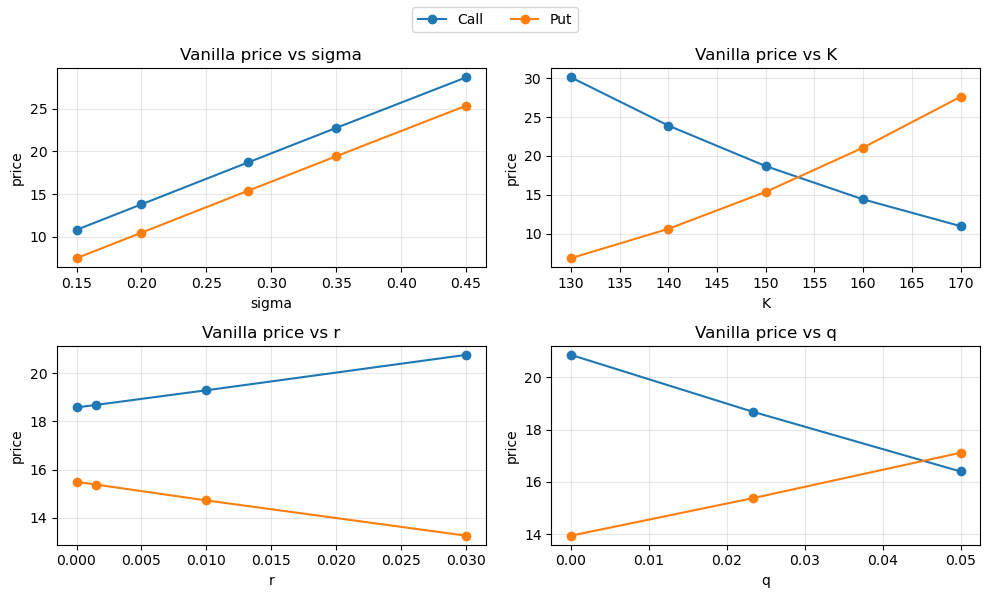

In [87]:
try:
    import matplotlib.pyplot as plt  # type: ignore

    def _plot_two(ax, df, xcol: str, title: str):
        ax.plot(df[xcol], df['call_price'], marker='o', label='Call')
        ax.plot(df[xcol], df['put_price'], marker='o', label='Put')
        ax.set_title(title)
        ax.set_xlabel(xcol)
        ax.set_ylabel('price')
        ax.grid(True, alpha=0.3)

    fig, axes = plt.subplots(2, 2, figsize=(10, 6))
    _plot_two(axes[0, 0], df_sigma, 'sigma', 'Vanilla price vs sigma')
    _plot_two(axes[0, 1], df_K, 'K', 'Vanilla price vs K')
    _plot_two(axes[1, 0], df_r, 'r', 'Vanilla price vs r')
    _plot_two(axes[1, 1], df_q, 'q', 'Vanilla price vs q')

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=2)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()
except Exception as e:
    print('skip plot:', e)
